<a href="https://colab.research.google.com/github/aarishaarif/Supervised-Machine-Learning-Models/blob/main/XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [347]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score

In [348]:
data = pd.read_csv('/content/ai_worker_burnout_attrition_2026.csv')
data.head()

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium


In [349]:
data.shape

(1500, 21)

In [350]:
data.isnull().sum()

,0
employee_id,0
job_role,0
years_experience,0
education_level,0
country,0
industry,0
company_size,0
remote_work_type,0
team_size,0
salary_usd_k,0


In [351]:
data.describe()

,years_experience,team_size,salary_usd_k,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5
count,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,9.947333,24.812667,140.734000,4.05600,4.233733,41.248667,4.985533,57.543333,50.057333,3.334733
std,5.460932,13.682582,59.717429,1.97403,2.148387,21.658214,2.913933,10.726952,11.437771,0.636692
min,1.000000,2.000000,40.000000,1.00000,0.500000,5.000000,0.000000,25.000000,16.000000,1.300000
25%,5.000000,13.000000,91.000000,2.00000,2.400000,22.750000,2.400000,50.000000,42.000000,2.900000
50%,10.000000,25.000000,139.000000,4.00000,4.200000,40.000000,5.000000,57.000000,50.000000,3.300000
75%,15.000000,36.000000,190.000000,6.00000,6.100000,60.000000,7.500000,65.000000,58.000000,3.800000
max,19.000000,49.000000,249.000000,7.00000,8.000000,79.000000,10.000000,95.000000,86.000000,5.000000


In [352]:
data.duplicated().sum()

np.int64(0)

In [353]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   employee_id                     1500 non-null   object 
 1   job_role                        1500 non-null   object 
 2   years_experience                1500 non-null   int64  
 3   education_level                 1500 non-null   object 
 4   country                         1500 non-null   object 
 5   industry                        1500 non-null   object 
 6   company_size                    1500 non-null   object 
 7   remote_work_type                1500 non-null   object 
 8   team_size                       1500 non-null   int64  
 9   salary_usd_k                    1500 non-null   int64  
 10  primary_ai_tool                 1500 non-null   object 
 11  ai_tools_used_per_day           1500 non-null   int64  
 12  hours_with_ai_assistance_daily  15

In [354]:
data.columns

Index(['employee_id', 'job_role', 'years_experience', 'education_level',
       'country', 'industry', 'company_size', 'remote_work_type', 'team_size',
       'salary_usd_k', 'primary_ai_tool', 'ai_tools_used_per_day',
       'hours_with_ai_assistance_daily', 'ai_replaces_my_tasks_pct',
       'ai_adoption_stage', 'weekly_ai_upskilling_hrs', 'productivity_score',
       'burnout_score', 'job_satisfaction_1_5', 'fear_of_ai_replacement',
       'attrition_risk'],
      dtype='object')

In [355]:
data['attrition_risk'].unique()

array(['Medium', 'Low', 'High'], dtype=object)

In [356]:
data['attrition_risk'].value_counts()

,count
attrition_risk,
Low,724
Medium,691
High,85


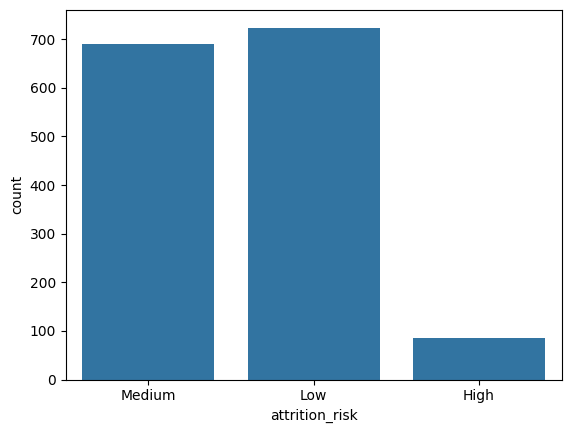

In [357]:
sns.countplot(x=data['attrition_risk'])
plt.show()

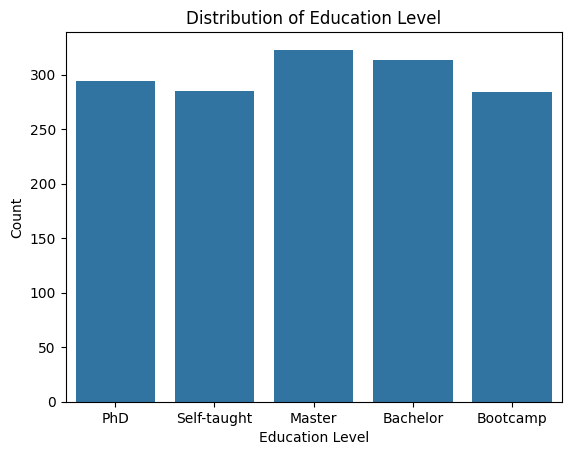

In [358]:
sns.countplot(x=temp_data['education_level'])
plt.title('Distribution of Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.show()

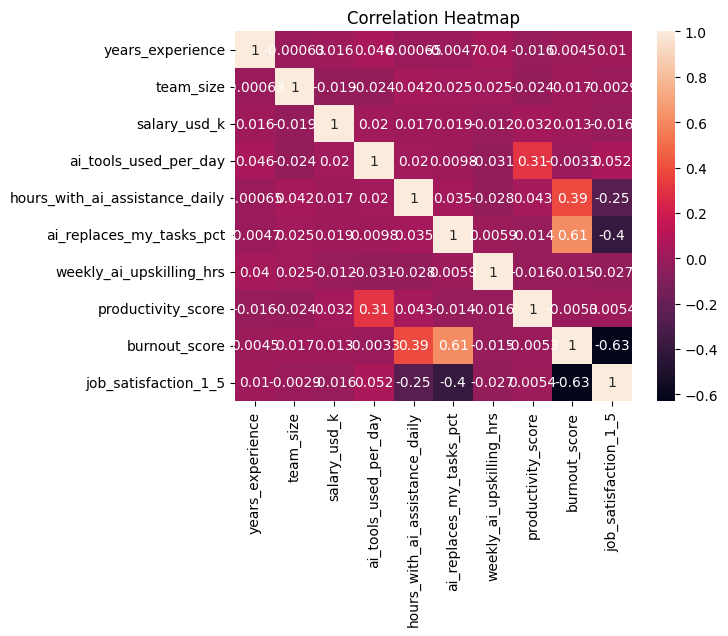

In [359]:
numeric_cols = data.select_dtypes(include='number').columns


sns.heatmap(data[numeric_cols].corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

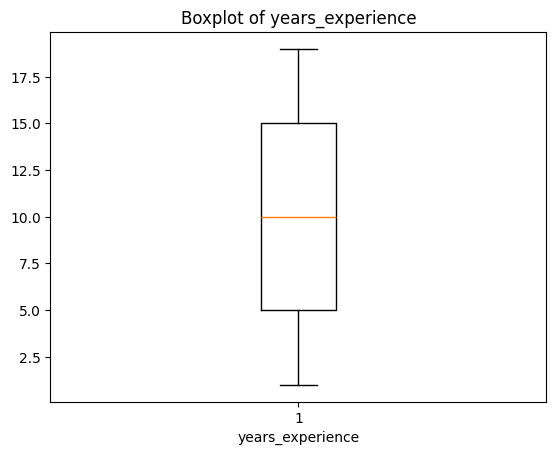

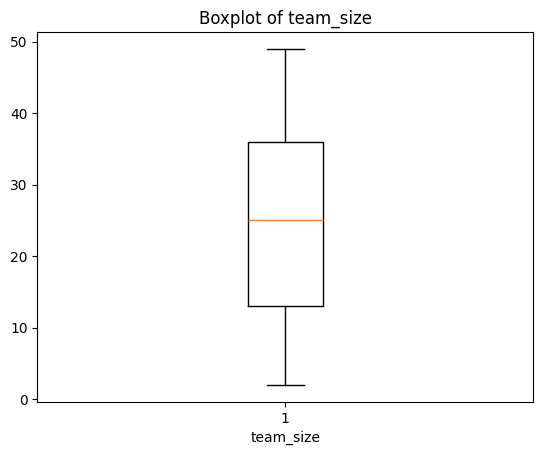

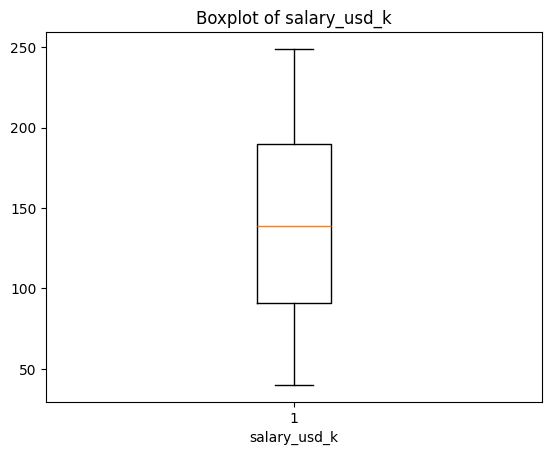

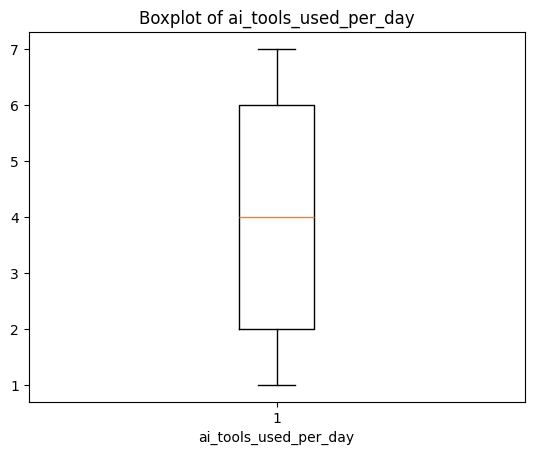

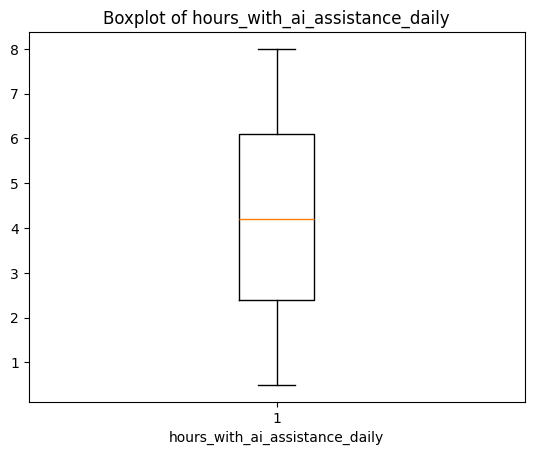

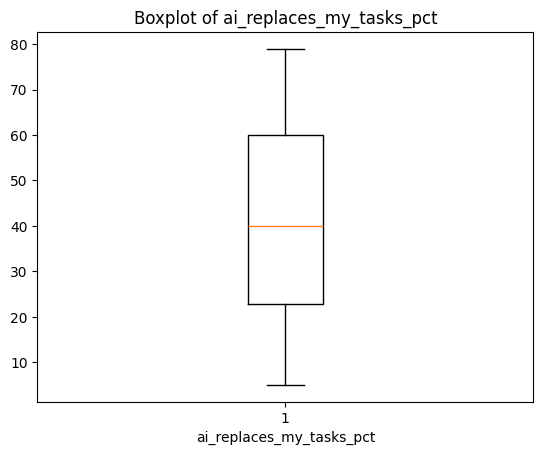

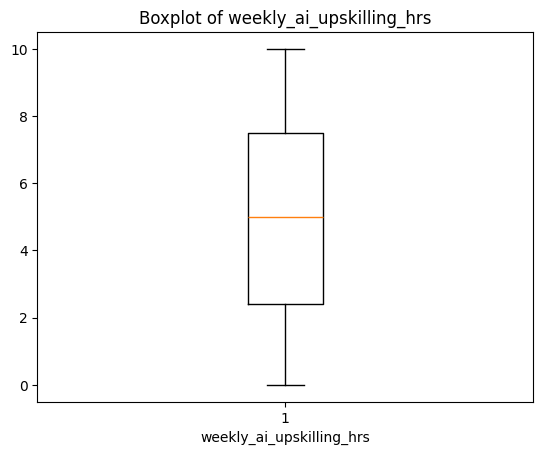

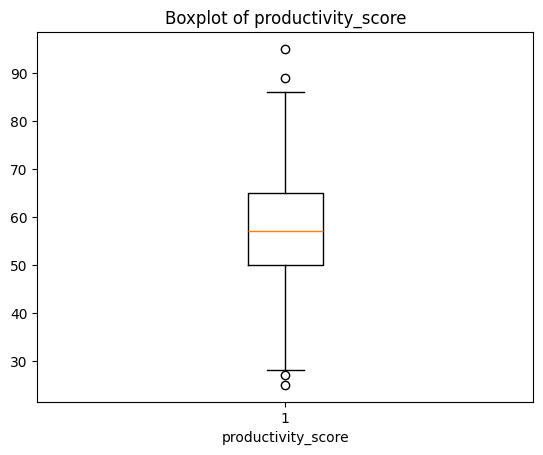

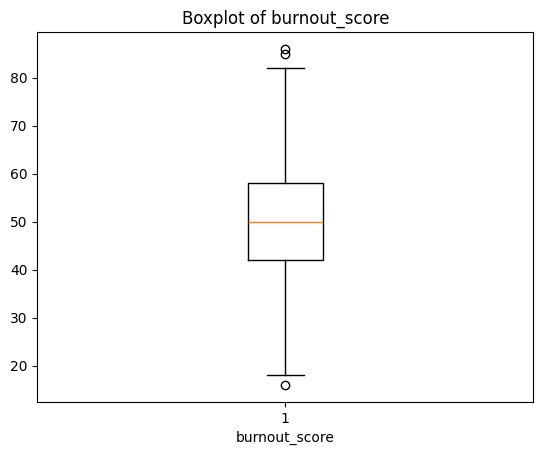

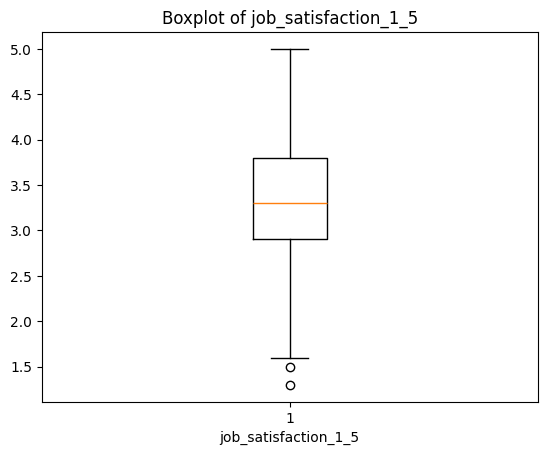

In [360]:
numeric_cols = data.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure()
    plt.boxplot(data[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [361]:
cols_to_cap =['productivity_score',	'burnout_score','job_satisfaction_1_5']
for cols in cols_to_cap:
    Q1 = data[cols].quantile(0.25)
    Q3 = data[cols].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[cols] = data[cols].clip(lower, upper)

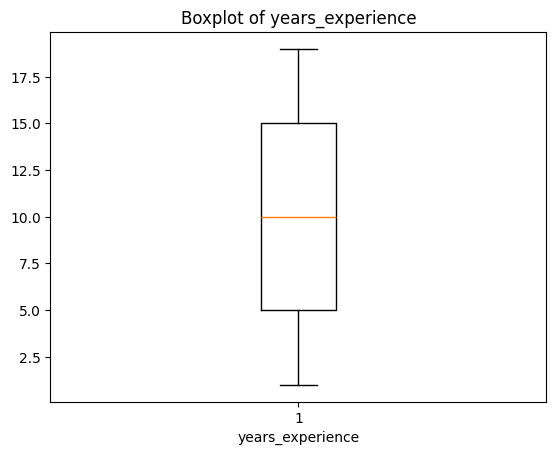

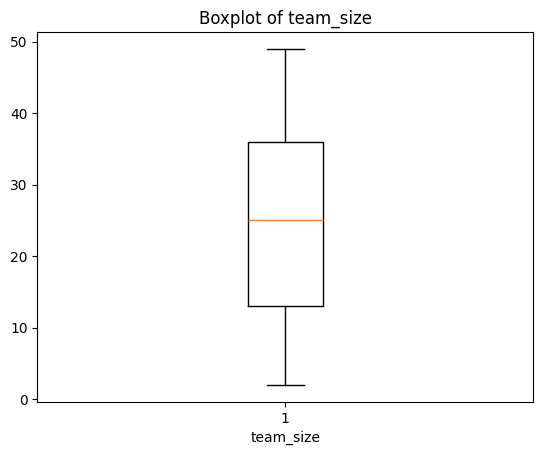

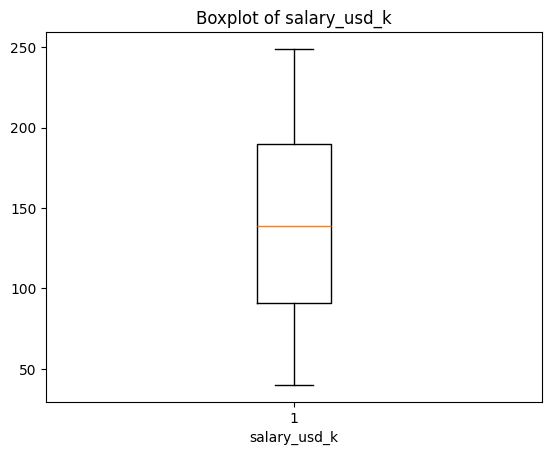

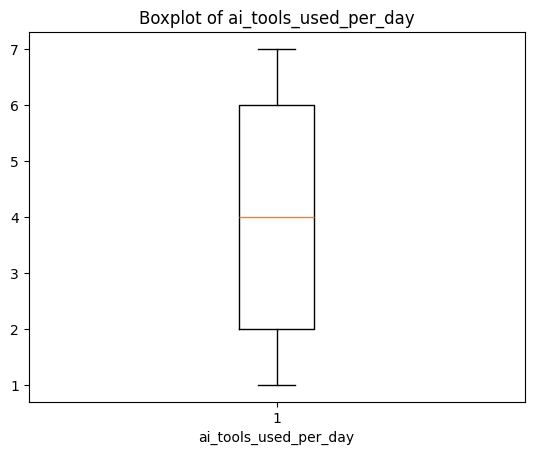

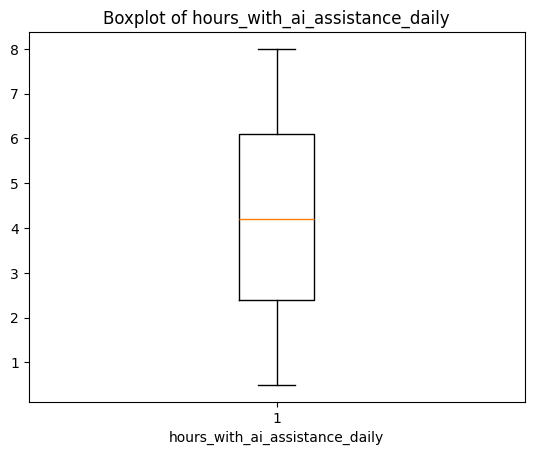

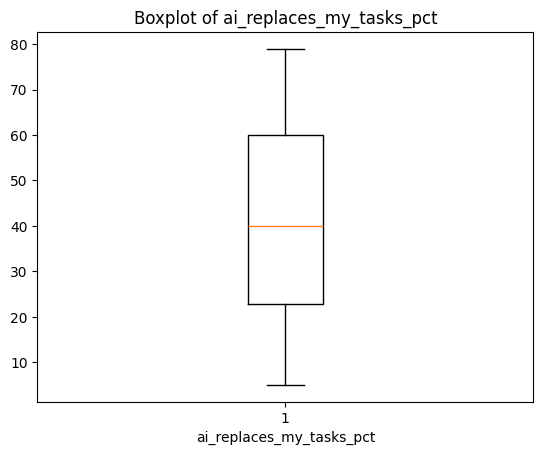

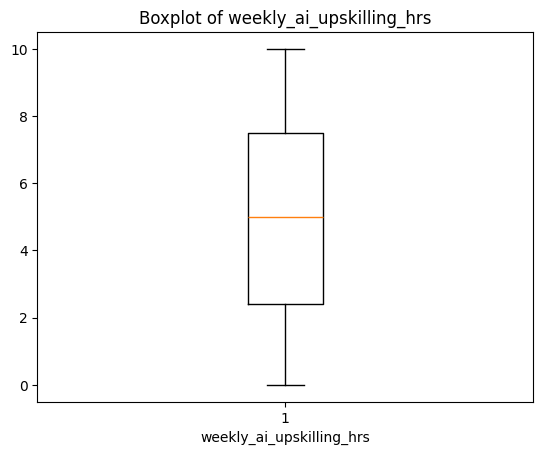

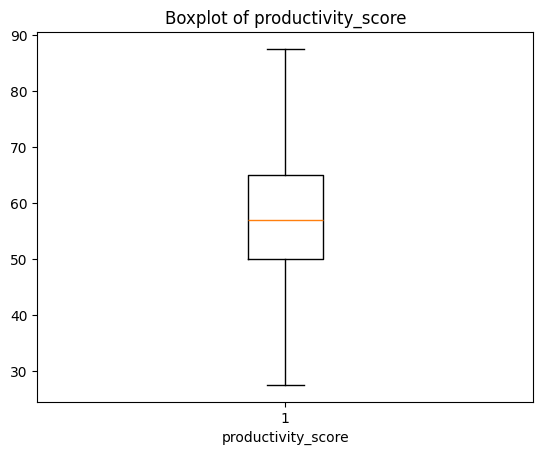

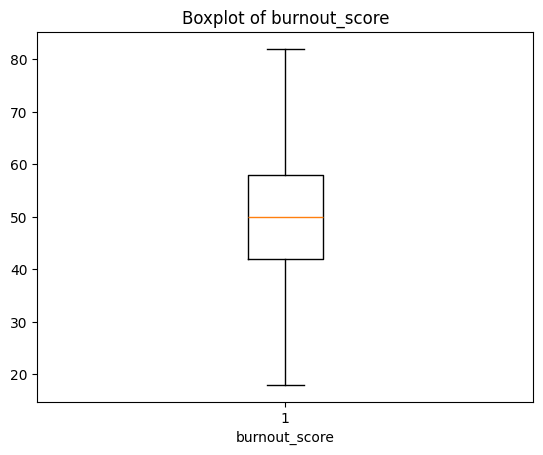

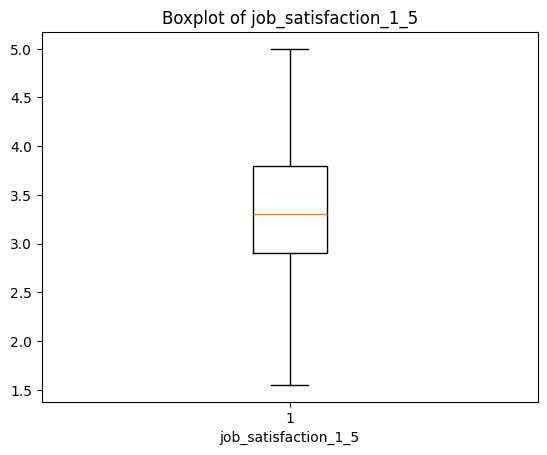

In [362]:
numeric_cols = data.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure()
    plt.boxplot(data[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [363]:
data['attrition_risk'].value_counts()

,count
attrition_risk,
Low,724
Medium,691
High,85


In [364]:
data = data.drop('employee_id', axis=1)

In [365]:
nominal_col=['job_role','education_level','country','industry','ai_adoption_stage','primary_ai_tool']
ordinal_col=['company_size','remote_work_type','fear_of_ai_replacement','attrition_risk']

In [366]:
data = pd.get_dummies(data, columns=nominal_col, drop_first=True)

In [367]:
le = LabelEncoder()
for col in ordinal_col:
    data[col] = le.fit_transform(data[col])

In [368]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 57 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   years_experience                 1500 non-null   int64  
 1   company_size                     1500 non-null   int64  
 2   remote_work_type                 1500 non-null   int64  
 3   team_size                        1500 non-null   int64  
 4   salary_usd_k                     1500 non-null   int64  
 5   ai_tools_used_per_day            1500 non-null   int64  
 6   hours_with_ai_assistance_daily   1500 non-null   float64
 7   ai_replaces_my_tasks_pct         1500 non-null   int64  
 8   weekly_ai_upskilling_hrs         1500 non-null   float64
 9   productivity_score               1500 non-null   float64
 10  burnout_score                    1500 non-null   int64  
 11  job_satisfaction_1_5             1500 non-null   float64
 12  fear_of_ai_replaceme

In [369]:
X = data.drop('attrition_risk', axis=1)
y = data['attrition_risk']

In [370]:
print(X.shape)
print(y.shape)

(1500, 56)
(1500,)


In [371]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [372]:
X_train , X_test , y_train , y_test = train_test_split(X_scaled , y , test_size=0.2 , random_state=42)

In [373]:
model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(y.unique()),
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='merror')

In [374]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='merror',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None, num_class=3, ...)

In [375]:
y_pred = model.predict(X_test)

In [376]:
y_prob = model.predict_proba(X_test)[:, 1]

In [377]:
# Removed: This manual thresholding is for binary classification and overwrites the correct multi-class predictions from model.predict(X_test)
# y_pred = (y_prob >= 0.28).astype(int)

In [378]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.87


In [379]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:",cm)

Confusion Matrix: [[  8   0   5]
 [  0 123  18]
 [  4  12 130]]


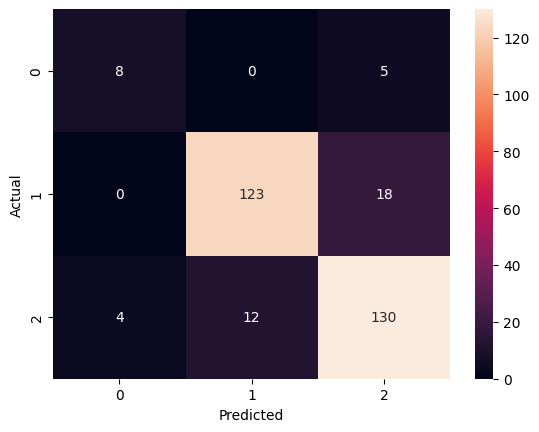

In [380]:
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [381]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.62      0.64        13
           1       0.91      0.87      0.89       141
           2       0.85      0.89      0.87       146

    accuracy                           0.87       300
   macro avg       0.81      0.79      0.80       300
weighted avg       0.87      0.87      0.87       300

